# MDKG Analysis

## Imports

In [23]:
import json
from itertools import combinations
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load Data

In [24]:
preds = json.load(open("../data/log/mdkg_eval/2026-04-26_05:11:51.821450/predictions_test_epoch_0.json"))
true = json.load(open("../data/datasets/mdkg/mdkg_test.json"))

## Edge Cases

In [25]:
def is_entity_mismatch(true_example, pred_example):
    true = {(entity["start"], entity["end"], entity["type"]) for entity in true_example["entities"]}
    pred = {(entity["start"], entity["end"], entity["type"]) for entity in pred_example["entities"]}
    return true != pred


def is_relation_mismatch(true_example, pred_example):
    true = {(relation["type"], relation["head"], relation["tail"]) for relation in true_example["relations"]}
    pred = {(relation["type"], relation["head"], relation["tail"]) for relation in pred_example["relations"]}
    return true != pred

In [26]:
edge_cases = []

for i in range(len(true)):
    entity_mismatch = is_entity_mismatch(true[i], preds[i])
    relation_mismatch = is_relation_mismatch(true[i], preds[i])

    if entity_mismatch or relation_mismatch:
        edge_cases.append({
            "index": i,
            "entity_mismatch": entity_mismatch,
            "relation_mismatch": relation_mismatch
        })

In [27]:
def show_case(i):
    print("\nTEXT:")
    print(" ".join(true[i]["tokens"]))

    print("\nTRUE ENTITIES:")
    for entity in true[i]["entities"]:
        print(entity)

    print("\nPRED ENTITIES:")
    for entity in preds[i]["entities"]:
        print(entity)

    print("\nTRUE RELATIONS:")
    for relation in true[i]["relations"]:
        print(relation)

    print("\nPRED RELATIONS:")
    for relation in preds[i]["relations"]:
        print(relation)

In [28]:
relation = [x["index"] for x in edge_cases if x["relation_mismatch"] and not x["entity_mismatch"]]

In [29]:
show_case(relation[7])


TEXT:
Musculoskeletal pain was assessed based on the Nordic questionnaire identifying nine possible pain points in the body .

TRUE ENTITIES:
{'start': 0, 'end': 2, 'type': 'disease'}
{'start': 7, 'end': 9, 'type': 'method'}
{'start': 12, 'end': 13, 'type': 'disease'}
{'start': 16, 'end': 17, 'type': 'region'}

PRED ENTITIES:
{'type': 'disease', 'start': 0, 'end': 2}
{'type': 'method', 'start': 7, 'end': 9}
{'type': 'disease', 'start': 12, 'end': 13}
{'type': 'region', 'start': 16, 'end': 17}

TRUE RELATIONS:
{'type': 'help_diagnose', 'head': 1, 'tail': 0}

PRED RELATIONS:
{'type': 'help_diagnose', 'head': 1, 'tail': 0}
{'type': 'located_in', 'head': 2, 'tail': 3}


## Performance Gaps

### Overlapping Entities

In [30]:
errors = []
correct = []

In [31]:
def has_overlap(entities):
    from itertools import combinations
    for entity_1, entity_2 in combinations(entities, 2):
        if entity_1["start"] < entity_2["end"] and entity_2["start"] < entity_1["end"]:
            return True
    return False

In [32]:
error_overlap = 0
error_total = 0

correct_overlap = 0
correct_total = 0

for i in range(len(true)):
    true_example = true[i]
    pred_example = preds[i]

    is_error = true_example["relations"] != pred_example["relations"]

    if has_overlap(true_example["entities"]):
        if is_error:
            error_overlap += 1
        error_total += 1
    else:
        if not is_error:
            correct_overlap += 1
        correct_total += 1

In [33]:
print("Overlap error rate:", error_overlap / error_total)
print("No-overlap error rate:", correct_overlap / correct_total)

Overlap error rate: 1.0
No-overlap error rate: 0.5550561797752809


### Long-Distance Dependencies

In [34]:
def avg_relation_distance(example):
    entity = example["entities"]
    distances = []

    for relation in example["relations"]:
        head = entity[relation["head"]]
        tail = entity[relation["tail"]]
        distances.append(abs(head["start"] - tail["start"]))

    if distances:
        return sum(distances) / len(distances)
    return 0

In [35]:
def is_error(i):
    return true[i]["relations"] != preds[i]["relations"]

In [36]:
error_distances = []
correct_distances = []

for i in range(len(preds)):
    distance = avg_relation_distance(true[i])

    if is_error(i):
        error_distances.append(distance)
    else:
        correct_distances.append(distance)

In [37]:
print("Avg distance (errors):", sum(error_distances)/len(error_distances))
print("Avg distance (correct):", sum(correct_distances)/len(correct_distances))

Avg distance (errors): 8.525413279744683
Avg distance (correct): 1.4571524966261808


In [38]:
def relation_distance(head, tail):
    return abs(head["start"] - tail["start"])

In [39]:
def get_bin(distance, bins):
    for b in bins:
        if b[0] <= distance < b[1]:
            return b
    return None

In [40]:
def compute_distance_bin_errors(preds, true):
    bins = [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8, 9), (9, 10), (10,100)]
    labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5-6", "6-7", "7-8", "8-9", "9-10", "10+"]

    stats = defaultdict(lambda: {"total": 0, "errors": 0})

    for i in range(len(preds)):

        for rel in true[i]["relations"]:

            head = true[i]["entities"][rel["head"]]
            tail = true[i]["entities"][rel["tail"]]

            distance = relation_distance(head, tail)

            bin = get_bin(distance, bins)

            stats[bin]["total"] += 1

            if true[i]["relations"] != preds[i]["relations"]:
                stats[bin]["errors"] += 1

    error_rates = []
    counts = []

    for bin in bins:
        total = stats[bin]["total"]
        errors = stats[bin]["errors"]

        if total > 0:
            error_rates.append(errors / total)
        else:
            error_rates.append(0)

        counts.append(total)

    return labels, error_rates, counts

In [41]:
def plot_distance_errors(preds, true, title="Error Rate vs Relation Distance"):
    labels, error_rates, counts = compute_distance_bin_errors(preds, true)

    plt.figure()
    plt.plot(labels, error_rates, marker="o")

    plt.xlabel("Relation Distance (tokens)")
    plt.ylabel("Error Rate")
    plt.title(title)

    plt.ylim(0, 1)
    plt.grid(True)

    filename = "mdkg_relation_distances_error_rate.png"
    filepath = os.path.join("../images", filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()

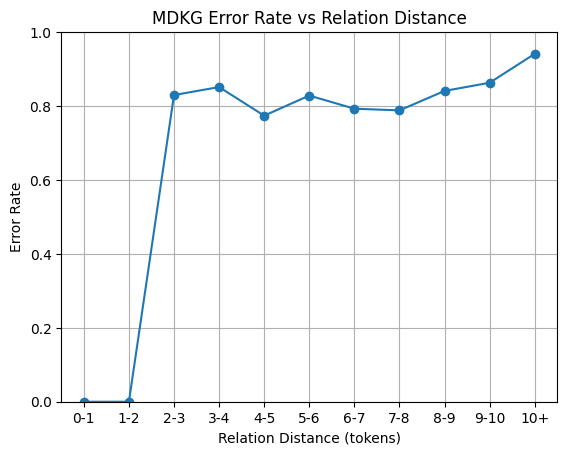

In [42]:
plot_distance_errors(preds, true, "MDKG Error Rate vs Relation Distance")